In [1]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

import numpy as np

manualSeed = 999
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(True)

# Data

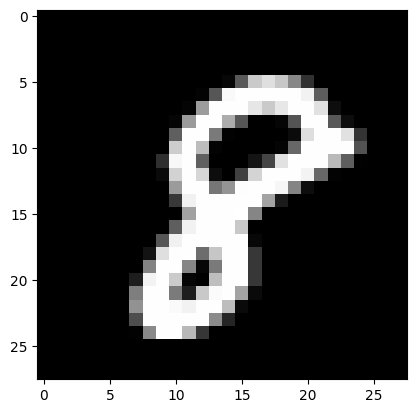

Labels:     8


In [2]:
from preprocessing.mnist import train_valid_test, display_sample, imshow

batch_size = 1
n_train = 100  # samples per class
n_valid = 400
classes = range(10)

trainloader, validloader, testloader = train_valid_test(classes, batch_size=batch_size, n_train=n_train, n_valid=n_valid)
display_sample(trainloader)

# Model Init

In [3]:
from models.quadnet import QuadraticNet
from models.switchable import Switchable
from train.eval import num_params
from train.config import device

arch = QuadraticNet

model = Switchable.from_model(arch(len(classes))).to(device)
print(f"{model.__class__.__name__} has {num_params(model)} parameters")

Switchable has 54366 parameters


# Training

In [4]:
from train.train import train
from train.validate import Validate

criterion = nn.CrossEntropyLoss()

In [5]:
num_models = 2
models: list[nn.Module] = []
validates: list[Validate] = []

for i in range(num_models):
    model.switch(0)
    (best_acc, best_model), validate = train(
        model, trainloader, validloader, criterion, 
        lr=0.002, epochs=30,
        val_gap=100, verbose=True
    )

    models.append((best_acc, best_model))
    validates.append(validate)

[1, 100] loss: 2.336
tensor([ 0.1373,  0.1648, -0.1177,  0.1145, -0.1678, -0.1540, -0.0465, -0.2521,
         0.0639,  0.1228], grad_fn=<SelectBackward0>) tensor(0)
Validation Accuracy: 0.100
[1, 200] loss: 2.287
tensor([ 0.0978,  0.1030, -0.0932,  0.1134, -0.1578, -0.1749, -0.0586, -0.2127,
         0.0654,  0.0966], grad_fn=<SelectBackward0>) tensor(5)
Validation Accuracy: 0.118
[1, 300] loss: 2.333
tensor([ 0.1410,  0.1137, -0.0793,  0.0237, -0.1694, -0.1972, -0.0782, -0.1773,
         0.0369,  0.0781], grad_fn=<SelectBackward0>) tensor(5)
Validation Accuracy: 0.114
[1, 400] loss: 2.105
tensor([ 0.1199,  0.0244, -0.0359,  0.1140, -0.1951, -0.1448, -0.1357, -0.2008,
         0.0964,  0.0605], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.189
[1, 500] loss: 2.288
tensor([-0.1078, -0.6881, -0.2505,  0.0409, -0.5449, -0.0449, -0.9156,  0.2960,
        -0.1898,  0.1992], grad_fn=<SelectBackward0>) tensor(4)
Validation Accuracy: 0.169
[1, 600] loss: 2.135
tensor([-2.5866e-01

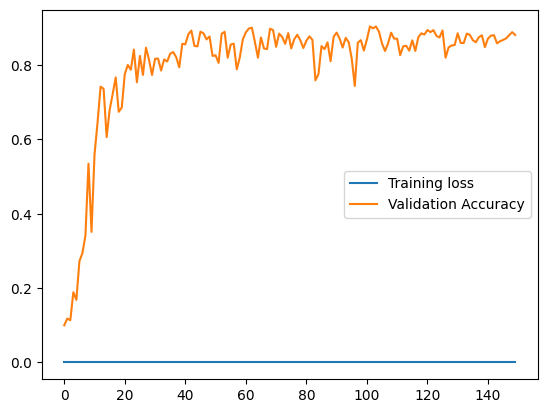

In [6]:
validates[0].show_history()

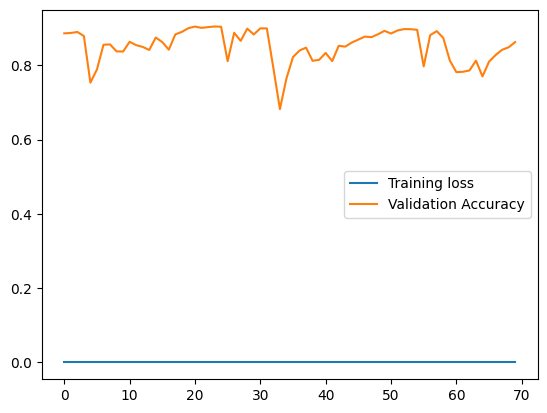

In [7]:
validates[1].show_history()

In [8]:
PATH = './trained_models/quadnet.pth'
torch.save(models[0][1].state_dict(), PATH)

# Model Evaluation

Accuracy of the model 0 on the test images with quantum layer: 90.86949152542373 %
Incorrectly predicted images


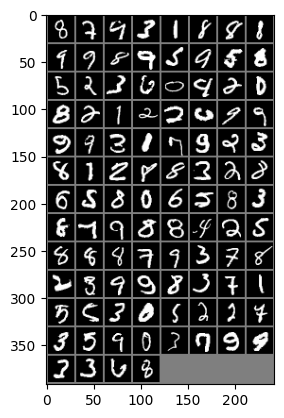

In [11]:
from train.eval import get_acc

acc, errors = get_acc(models[0][1], testloader)
print(f'Accuracy of the model 0 on the test images with quantum layer: {100 * acc} %')

print("Incorrectly predicted images")
imshow(torchvision.utils.make_grid(errors[:100]))

Accuracy of the model 1 on the test images with quantum layer: 91.82372881355933 %
Incorrectly predicted images


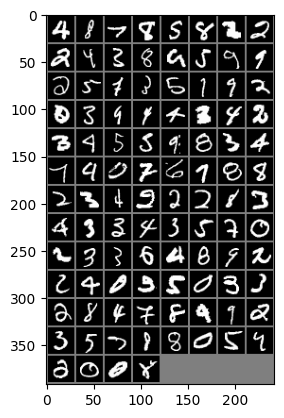

In [12]:
from train.eval import get_acc

acc, errors = get_acc(models[1][1], testloader)
print(f'Accuracy of the model 1 on the test images with quantum layer: {100 * acc} %')

print("Incorrectly predicted images")
imshow(torchvision.utils.make_grid(errors[:100]))